In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import seaborn as sns
from scipy.integrate import quad
import torch
from torch import nn
from datetime import datetime
from matplotlib.gridspec import GridSpec
from tensorboard.backend.event_processing import event_accumulator

from copy import deepcopy

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import CallbackList, EvalCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecMonitor

### Add mbt-gym to path

In [4]:
import sys
sys.path.append("../../")

In [5]:
from mbt_gym.gym.ModelDynamics import LimitOrderModelDynamics
from mbt_gym.agents.BaselineAgents import *
from mbt_gym.stochastic_processes.midprice_models import *
from mbt_gym.stochastic_processes.arrival_models import *
from mbt_gym.stochastic_processes.fill_probability_models import *

# helpers
from mbt_gym.gym.TradingEnvironment import TradingEnvironment
from mbt_gym.gym.StableBaselinesTradingEnvironment import StableBaselinesTradingEnvironment
from mbt_gym.gym.index_names import *
from mbt_gym.gym.helpers.plotting import *
from mbt_gym.gym.helpers.generate_trajectory import generate_trajectory
from mbt_gym.gym.wrappers import *

In [6]:
seed_value = 42
global seed  
seed = seed_value

# Reset seeds for all randomness sources
np.random.seed(seed)
torch.manual_seed(seed)

### Parameters

In [7]:
max_inventory = 20

In [8]:
initial_price = 100
terminal_time = 1.0
sigma = 1.0
n_steps = 1000
initial_inventory = 0
fads_proportion = 0.6 # p is defined directly inside the ArithmeticBrownianMotionWithFadsMidpriceModel class as sqrt(1-q^2)
eta = 10
phi = 15
k = 1
fill_exponent = k
gamma = k
alpha=0.001
mu=0
big_phi=0.1

In [9]:
# OU parameters
u0 = 0.0
xi = 1.0

def m(t):
    return u0 * np.exp(-eta * t)

def v(t):
    return (xi**2) / (2.0 * eta) * (1.0 - np.exp(-2.0 * eta * t))

def compute_psi(q):
    c = gamma * sigma * q
    def integrand(t):
        return np.exp(c * m(t) + 0.5 * (c**2) * v(t))
    denom, _ = quad(integrand, 0.0, terminal_time)
    return (30.0 - phi * terminal_time) / denom

# compute psi for each fad proportion
psi = compute_psi(fads_proportion)

print("psi value:", psi)

psi value: 14.872283180889763


In [10]:
def get_closed_form_env(num_trajectories:int = 1, fads_proportion:float=0.6, 
               psi:float = 15.0, phi:float = 15.0, eta:float = 10.0,
               gamma:float = 1.0,
               ) -> TradingEnvironment:
    midprice_model = ArithmeticBrownianMotionWithFadsMidpriceModel(initial_price=initial_price, drift=mu,
                                                 volatility=sigma, fads_proportion=fads_proportion, eta=eta, step_size=terminal_time/n_steps,
                                                 terminal_time=terminal_time,
                                                 num_trajectories=num_trajectories, seed=seed)
    arrival_model = ModifiedPoissonArrivalModel(phi=phi,
                                                psi=psi,
                                                gamma=gamma,
                                                fads_proportion=fads_proportion,
                                                sigma=sigma,
                                                step_size=terminal_time/n_steps,
                                                num_trajectories=num_trajectories,
                                                seed=seed)
    fill_probability_model = ExponentialFillFunction(fill_exponent=k, 
                                                     step_size=terminal_time/n_steps,
                                                     num_trajectories=num_trajectories,
                                                     seed=seed)
    LOtrader = LimitOrderModelDynamics(midprice_model = midprice_model, arrival_model = arrival_model, 
                                fill_probability_model = fill_probability_model,
                                num_trajectories = num_trajectories, seed=seed)
    reward = CjMmCriterion(per_step_inventory_aversion = big_phi,
                           terminal_inventory_aversion = alpha,
                           terminal_time = terminal_time)
    env_params = dict(terminal_time=terminal_time, 
                      n_steps=n_steps,
                      seed = seed,
                      initial_inventory = initial_inventory,
                      model_dynamics = LOtrader,
                      reward_function = reward,
                      max_inventory=max_inventory,
                      normalise_action_space = False,
                      normalise_observation_space = False,
                      normalise_rewards = False,
                      num_trajectories=num_trajectories)
    return TradingEnvironment(**env_params)

In [11]:
fi_env = get_closed_form_env(fads_proportion=fads_proportion, psi=psi, phi=phi, eta=eta, gamma=gamma)

In [12]:
fi_agent = OptimizedFullInfoMMwithFadsInformedUniformedTradersAgent(env=fi_env)
print(fi_env.model_dynamics
      .midprice_model)


✓ Pre-computed ODE solutions for 1000 time points


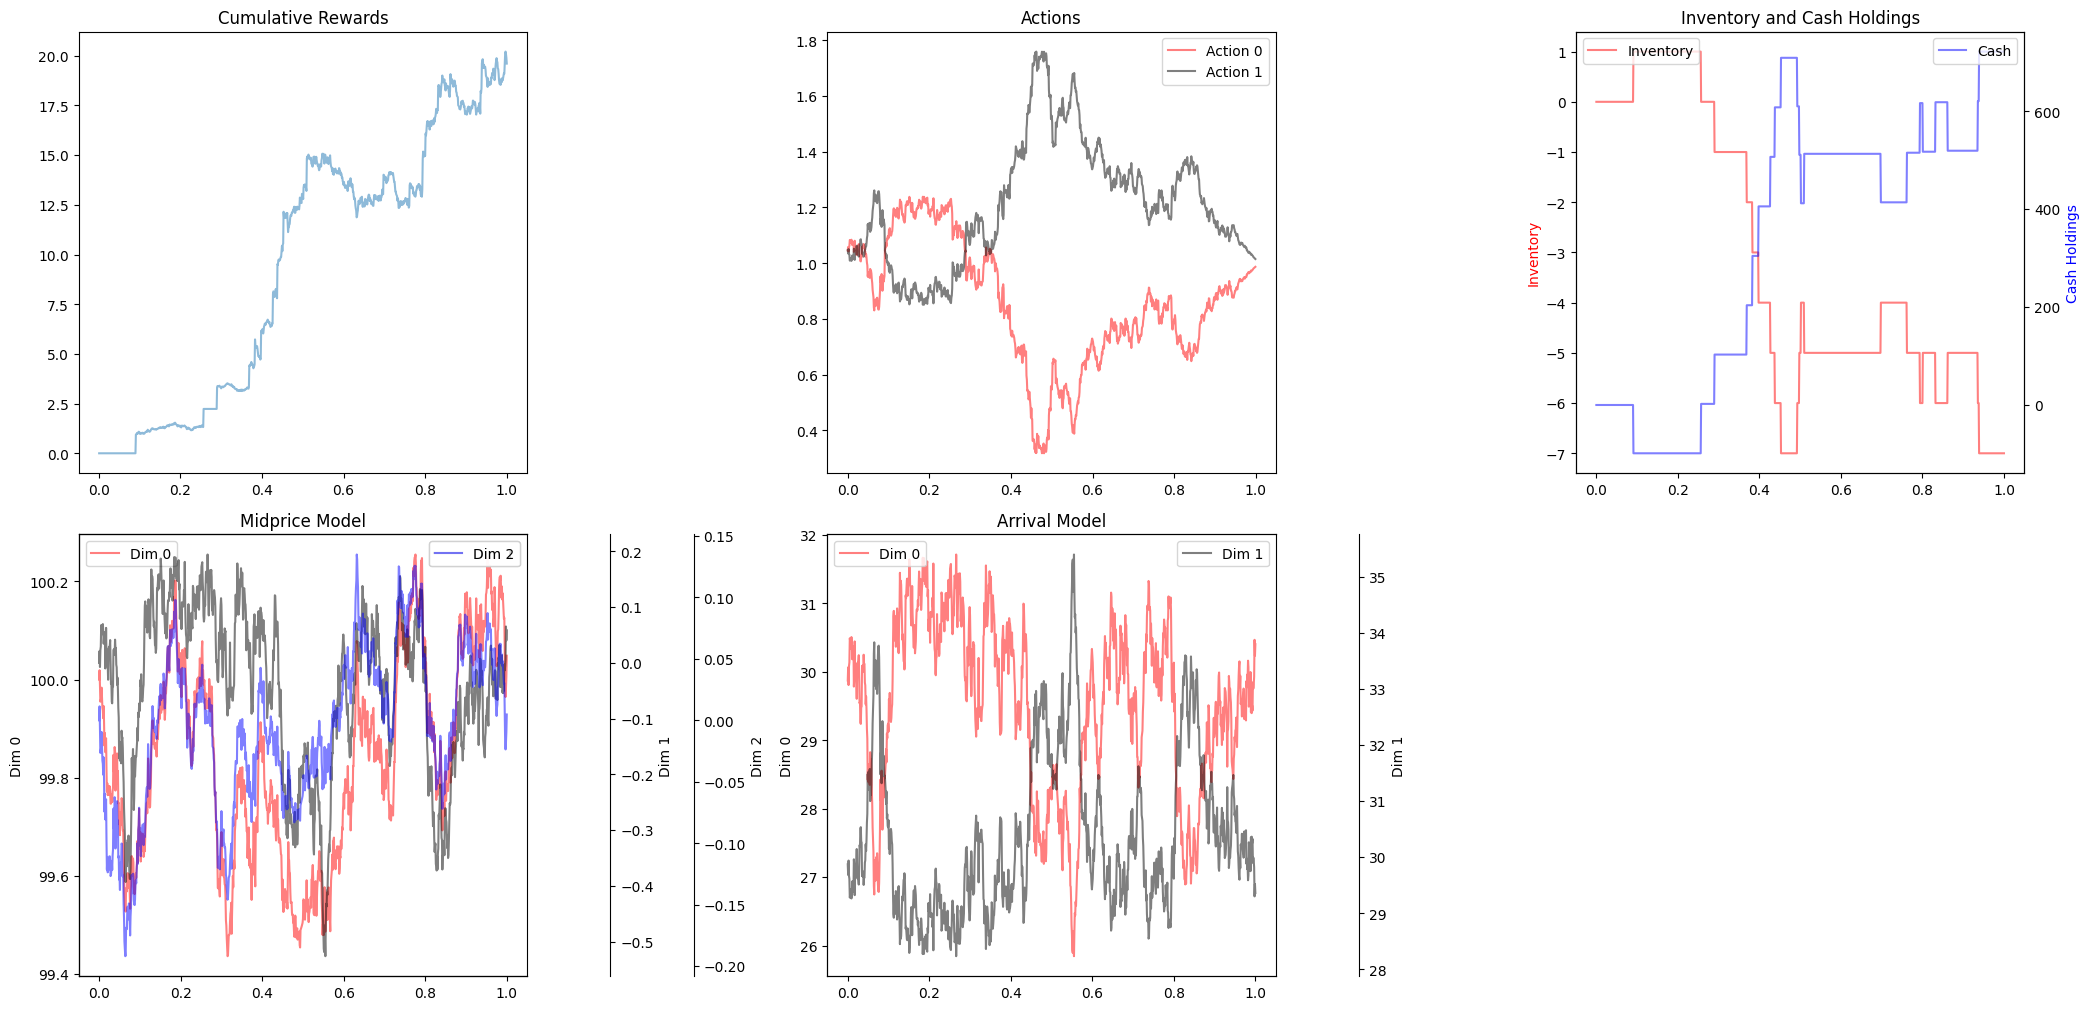

In [13]:
plot_trajectory_extended(fi_env, fi_agent)

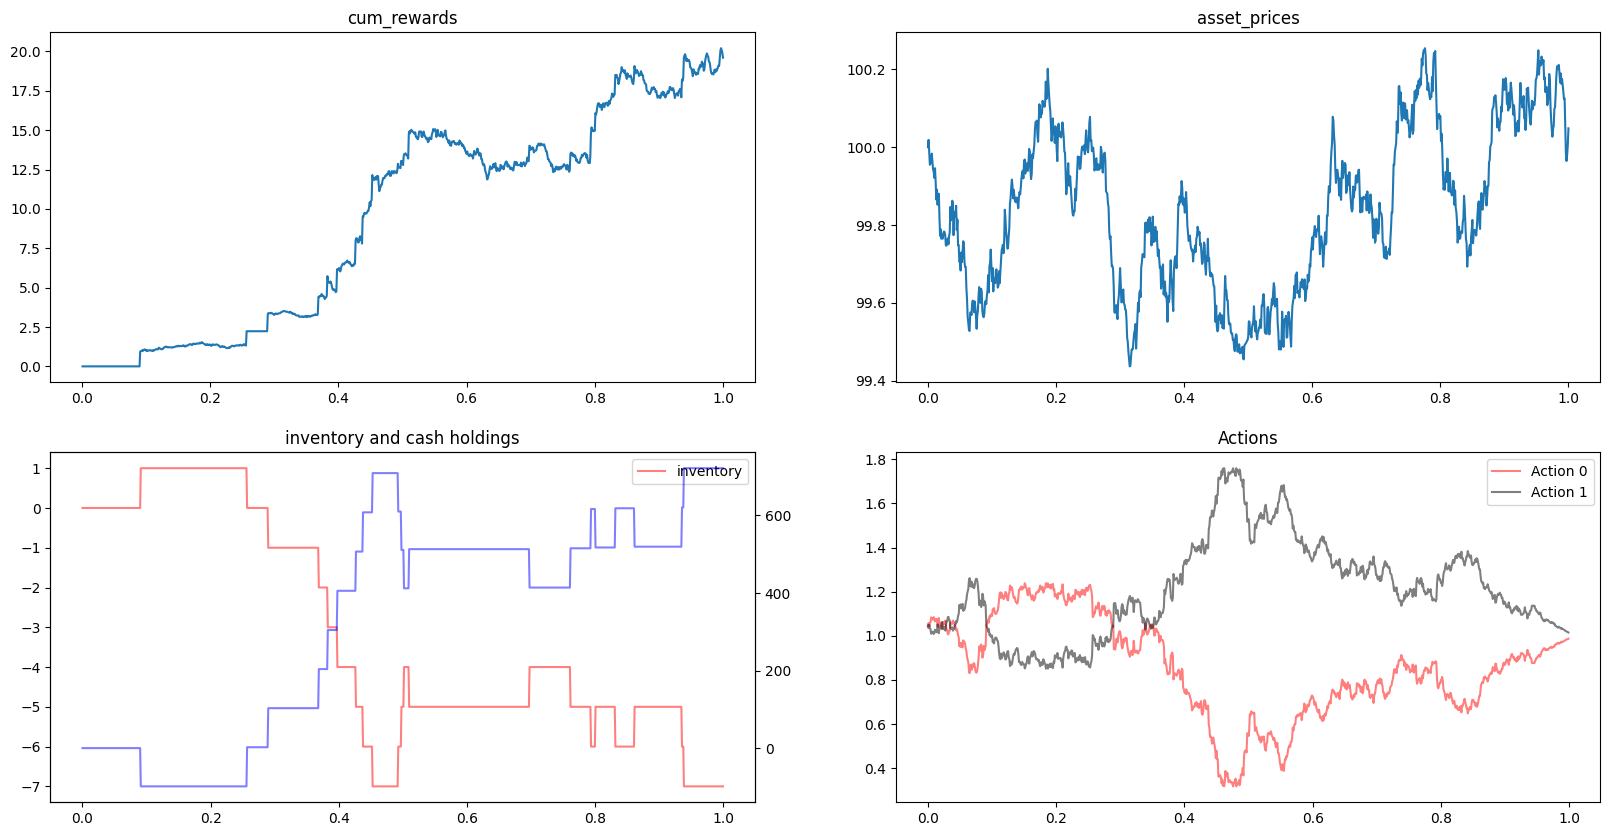

In [14]:
plot_trajectory(fi_env, fi_agent, seed = seed)

In [15]:
num_trajectories = 1000
vec_env_fi = get_closed_form_env(num_trajectories, fads_proportion=fads_proportion, psi=psi, phi=phi, eta=eta, gamma=gamma)
vec_agent_fi = OptimizedFullInfoMMwithFadsInformedUniformedTradersAgent(env=vec_env_fi)

print(vec_env_fi.model_dynamics
      .midprice_model)

✓ Pre-computed ODE solutions for 1000 time points


In [16]:
observations_fi, actions_fi, rewards_fi = generate_trajectory(vec_env_fi, vec_agent_fi)

In [17]:
results_fi, fig_fi, total_rewards_fi = generate_results_table_and_hist(vec_env=vec_env_fi,agent=vec_agent_fi)

In [18]:
results_fi

,Mean spread,Mean PnL,Std PnL,Mean terminal inventory,Std terminal inventory
Inventory,2.065432,21.259366,4.896308,-0.098,3.100386


### Rinforncement Learning

In [19]:
def get_rl_env(num_trajectories:int = 1, fads_proportion:float=0.6, 
               psi:float = 15.0, phi:float = 15.0, eta:float = 10.0,
               gamma:float = 1.0,
               ) -> TradingEnvironment:
    midprice_model = ArithmeticBrownianMotionWithFadsMidpriceModel(initial_price=initial_price, drift=mu,
                                                 volatility=sigma, fads_proportion=fads_proportion, eta=eta, step_size=terminal_time/n_steps,
                                                 terminal_time=terminal_time,
                                                 num_trajectories=num_trajectories, seed=seed)
    arrival_model = ModifiedPoissonArrivalModel(phi=phi,
                                                psi=psi,
                                                gamma=gamma,
                                                fads_proportion=fads_proportion,
                                                sigma=sigma,
                                                step_size=terminal_time/n_steps,
                                                num_trajectories=num_trajectories,
                                                seed=seed)
    fill_probability_model = ExponentialFillFunction(fill_exponent=k, 
                                                     step_size=terminal_time/n_steps,
                                                     num_trajectories=num_trajectories,
                                                     seed=seed)
    LOtrader = LimitOrderModelDynamics(midprice_model = midprice_model, arrival_model = arrival_model, 
                                fill_probability_model = fill_probability_model,
                                num_trajectories = num_trajectories, seed=seed)
    reward = CjMmCriterion(per_step_inventory_aversion = big_phi,
                           terminal_inventory_aversion = alpha,
                           terminal_time = terminal_time)
    env_params = dict(terminal_time=terminal_time, 
                      n_steps=n_steps,
                      seed = seed,
                      initial_inventory = initial_inventory,
                      #initial_inventory = random_initial_inventory,
                      #start_time = make_random_start_time_sampler(terminal_time),
                      model_dynamics = LOtrader,
                      reward_function = reward,
                      max_inventory=max_inventory,
                      normalise_action_space = False,
                      normalise_observation_space = False,
                      normalise_rewards = False,
                      num_trajectories=num_trajectories)
    return TradingEnvironment(**env_params)

In [20]:
def get_rl_env_visualization(num_trajectories:int = 1, fads_proportion:float=0.6, 
               psi:float = 15.0, phi:float = 15.0, eta:float = 10.0,
               gamma:float = 1.0,
               ) -> TradingEnvironment:
    midprice_model = ArithmeticBrownianMotionWithFadsMidpriceModel(initial_price=initial_price, drift=mu,
                                                 volatility=sigma, fads_proportion=fads_proportion, eta=eta, step_size=terminal_time/n_steps,
                                                 terminal_time=terminal_time,
                                                 num_trajectories=num_trajectories, seed=seed)
    arrival_model = ModifiedPoissonArrivalModel(phi=phi,
                                                psi=psi,
                                                gamma=gamma,
                                                fads_proportion=fads_proportion,
                                                sigma=sigma,
                                                step_size=terminal_time/n_steps,
                                                num_trajectories=num_trajectories,
                                                seed=seed)
    fill_probability_model = ExponentialFillFunction(fill_exponent=k, 
                                                     step_size=terminal_time/n_steps,
                                                     num_trajectories=num_trajectories,
                                                     seed=seed)
    LOtrader = LimitOrderModelDynamics(midprice_model = midprice_model, arrival_model = arrival_model, 
                                fill_probability_model = fill_probability_model,
                                num_trajectories = num_trajectories, seed=seed)
    reward = CjMmCriterion(per_step_inventory_aversion = big_phi,
                           terminal_inventory_aversion = alpha,
                           terminal_time = terminal_time)
    env_params = dict(terminal_time=terminal_time, 
                      n_steps=n_steps,
                      seed = seed,
                      initial_inventory = initial_inventory,
                      #initial_inventory = random_initial_inventory,
                      #start_time = make_random_start_time_sampler(terminal_time),
                      model_dynamics = LOtrader,
                      reward_function = reward,
                      max_inventory = max_inventory,
                      normalise_action_space = False,
                      normalise_observation_space = False,
                      normalise_rewards = False,
                      num_trajectories=num_trajectories)
    return TradingEnvironment(**env_params)

#### Optuna

In [21]:
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler

In [22]:
use_normalized_agent = False

In [23]:
def objective(trial):
    """
    Objective function for Optuna to optimize PPO hyperparameters.
    
    Parameters
    ----------
    trial : optuna.Trial
        A trial object that suggests hyperparameters
        
    Returns
    -------
    float
        Mean reward from evaluation episodes
    """
    batch_size_divisor = 100 

    # Suggest hyperparameters
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True)
    n_epochs = trial.suggest_int("n_epochs", 3, 10)
    # batch_size_divisor = trial.suggest_int("batch_size_divisor", 5, 20)
    # gamma = trial.suggest_float("gamma", 0.9, 0.999)
    gae_lambda = trial.suggest_float("gae_lambda", 0.9, 0.99)
    clip_range = trial.suggest_float("clip_range", 0.1, 0.3)
    ent_coef = trial.suggest_float("ent_coef", 0.0, 0.1)
    vf_coef = trial.suggest_float("vf_coef", 0.1, 1.0)
    max_grad_norm = trial.suggest_float("max_grad_norm", 0.3, 1.0)
    
    # Network architecture
    n_layers = trial.suggest_int("n_layers", 1, 3)
    layer_size = trial.suggest_categorical("layer_size", [128, 256, 512])
    activation = trial.suggest_categorical("activation", ["tanh", "relu"])
    
    # Build network architecture
    net_arch = []
    for _ in range(n_layers):
        net_arch.append(layer_size)
    
    activation_fn = nn.Tanh if activation == "tanh" else nn.ReLU
    
    policy_kwargs = dict(
        activation_fn=activation_fn,
        net_arch=dict(pi=net_arch.copy(), vf=net_arch.copy())
    )
    
    # Create environment for this trial
    num_trajectories = 1000
    reduced_training_indices = [INVENTORY_INDEX, TIME_INDEX, ASSET_PRICE_INDEX, FADS_INDEX]
    rl_env_trial = ReduceStateSizeWrapper(get_rl_env(num_trajectories), reduced_training_indices)
    sb_rl_env_trial = StableBaselinesTradingEnvironment(trading_env=rl_env_trial)
    sb_rl_env_trial = VecMonitor(sb_rl_env_trial)
    
    # Create model with suggested hyperparameters
    model = PPO(
        policy='MlpPolicy',
        env=sb_rl_env_trial,
        learning_rate=learning_rate,
        n_epochs=n_epochs,
        batch_size=int(n_steps * num_trajectories / batch_size_divisor),
        n_steps=int(n_steps),
        # gamma=gamma,
        gae_lambda=gae_lambda,
        clip_range=clip_range,
        ent_coef=ent_coef,
        vf_coef=vf_coef,
        max_grad_norm=max_grad_norm,
        policy_kwargs=policy_kwargs,
        verbose=0,
        device="cpu"
    )
    
    # Create evaluation callback with pruning
    eval_freq = 100_000  # Evaluate every 50k steps
    n_eval_episodes = 256
    
    # Custom callback for Optuna pruning
    class OptunaEvalCallback(EvalCallback):
        def __init__(self, trial, *args, **kwargs):
            super().__init__(*args, **kwargs)
            self.trial = trial
            self.eval_idx = 0
            
        def _on_step(self) -> bool:
            result = super()._on_step()
            
            if len(self.evaluations_results) > 0:
                # Report intermediate value
                mean_reward = self.evaluations_results[-1]
                self.trial.report(mean_reward, self.eval_idx)
                self.eval_idx += 1
                
                # Prune trial if needed
                if self.trial.should_prune():
                    raise optuna.TrialPruned()
            
            return result
    
    eval_callback = OptunaEvalCallback(
        trial=trial,
        eval_env=sb_rl_env_trial,
        n_eval_episodes=n_eval_episodes,
        eval_freq=eval_freq,
        deterministic=True,
        verbose=0
    )
    
    try:
        # Train for a limited number of steps 
        total_timesteps = 1_000_000  
        model.learn(total_timesteps=total_timesteps, callback=eval_callback)
        
        # Final evaluation
        rl_env_eval = get_rl_env_visualization(num_trajectories=1000)
        ppo_agent = SbAgent(
            model, 
            reduced_training_indices=reduced_training_indices, 
            env=rl_env_eval, 
            use_normalized_agent=use_normalized_agent
        )
        
        observations_rl, actions_rl, rewards_rl = generate_trajectory_rl(
            env=rl_env_eval, 
            rl_agent=ppo_agent
        )
        
        mean_reward = rewards_rl.sum(axis=-1).mean()
        
    except optuna.TrialPruned:
        raise
    except Exception as e:
        print(f"Trial failed with error: {e}")
        return float('-inf')
    finally:
        # Clean up
        sb_rl_env_trial.close()
    
    return mean_reward

In [24]:
# Create study
study = optuna.create_study(
    direction="maximize",
    study_name="ppo_mm_optimization",
    sampler=TPESampler(seed=seed),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=10)
)

# Optimize
n_trials = 50  # Number of trials to run
study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

# Print results
print("Best trial:")
print(f"  Value (mean reward): {study.best_trial.value}")
print(f"  Params: ")
for key, value in study.best_trial.params.items():
    print(f"    {key}: {value}")

[I 2025-11-03 11:52:32,078] A new study created in memory with name: ppo_mm_optimization


  0%|          | 0/50 [00:00<?, ?it/s]

/opt/anaconda3/envs/mtb_gym_env/lib/python3.10/site-packages/gymnasium/spaces/box.py:225: RuntimeWarning: overflow encountered in cast
  elif low.dtype != self.dtype and np.any(low < dtype_min):
/opt/anaconda3/envs/mtb_gym_env/lib/python3.10/site-packages/gymnasium/spaces/box.py:295: RuntimeWarning: overflow encountered in cast
  elif high.dtype != self.dtype and np.any(dtype_max < high):


[I 2025-11-03 11:53:42,019] Trial 0 finished with value: -1.9004642903490596 and parameters: {'learning_rate': 5.6115164153345e-05, 'n_epochs': 10, 'gae_lambda': 0.9658794547630265, 'clip_range': 0.21973169683940733, 'ent_coef': 0.015601864044243652, 'vf_coef': 0.2403950683025824, 'max_grad_norm': 0.3406585285177396, 'n_layers': 3, 'layer_size': 256, 'activation': 'tanh'}. Best is trial 0 with value: -1.9004642903490596.


/opt/anaconda3/envs/mtb_gym_env/lib/python3.10/site-packages/gymnasium/spaces/box.py:225: RuntimeWarning: overflow encountered in cast
  elif low.dtype != self.dtype and np.any(low < dtype_min):
/opt/anaconda3/envs/mtb_gym_env/lib/python3.10/site-packages/gymnasium/spaces/box.py:295: RuntimeWarning: overflow encountered in cast
  elif high.dtype != self.dtype and np.any(dtype_max < high):


[I 2025-11-03 11:54:19,656] Trial 1 finished with value: -2.0658227286874844 and parameters: {'learning_rate': 2.6587543983272695e-05, 'n_epochs': 4, 'gae_lambda': 0.9165064058868091, 'clip_range': 0.16084844859190756, 'ent_coef': 0.052475643163223784, 'vf_coef': 0.4887505167779042, 'max_grad_norm': 0.5038603981386293, 'n_layers': 2, 'layer_size': 512, 'activation': 'relu'}. Best is trial 0 with value: -1.9004642903490596.
[I 2025-11-03 11:54:37,920] Trial 2 finished with value: 0.5340769221926451 and parameters: {'learning_rate': 2.5081156860452307e-05, 'n_epochs': 7, 'gae_lambda': 0.9533173111975838, 'clip_range': 0.10929008254399955, 'ent_coef': 0.06075448519014384, 'vf_coef': 0.2534717113185624, 'max_grad_norm': 0.3455361150896957, 'n_layers': 3, 'layer_size': 128, 'activation': 'relu'}. Best is trial 2 with value: 0.5340769221926451.
[I 2025-11-03 11:54:45,369] Trial 3 finished with value: -2.5996360063195163 and parameters: {'learning_rate': 7.591104805282687e-05, 'n_epochs': 3, 

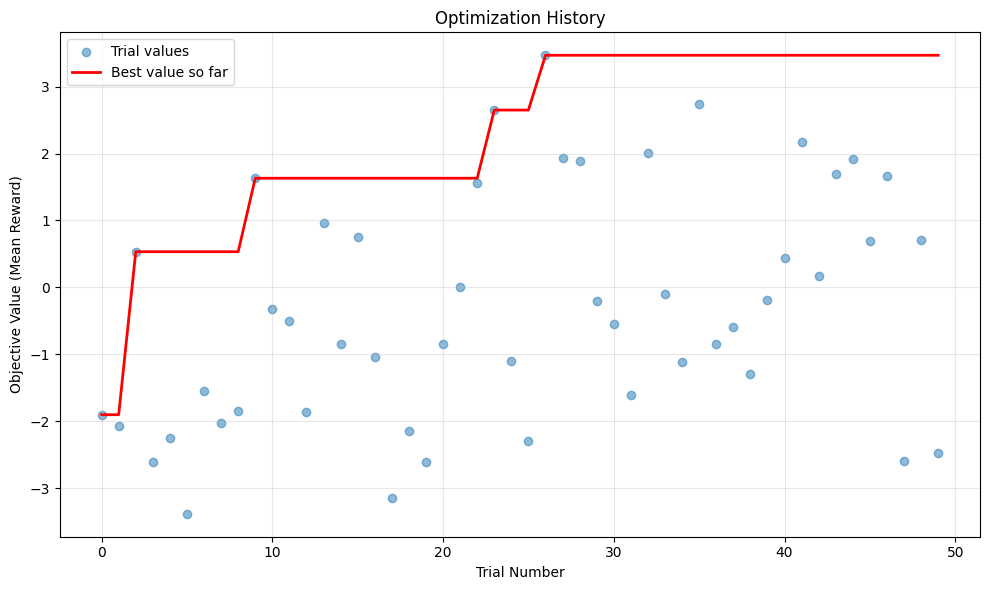

In [25]:
# Get the study results as a DataFrame
df = study.trials_dataframe()

# 1. Optimization History Plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot all trial values
ax.scatter(df['number'], df['value'], alpha=0.5, label='Trial values')

# Plot best value so far (cumulative best)
best_values = df['value'].cummax()
ax.plot(df['number'], best_values, 'r-', linewidth=2, label='Best value so far')

ax.set_xlabel('Trial Number')
ax.set_ylabel('Objective Value (Mean Reward)')
ax.set_title('Optimization History')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# Get best parameters
best_params = study.best_trial.params

batch_size_divisor = 100

# Extract parameters
learning_rate = best_params["learning_rate"]
n_epochs = best_params["n_epochs"]
# batch_size_divisor = best_params["batch_size_divisor"]
#gamma = best_params["gamma"]
gae_lambda = best_params["gae_lambda"]
clip_range = best_params["clip_range"]
ent_coef = best_params["ent_coef"]
vf_coef = best_params["vf_coef"]
max_grad_norm = best_params["max_grad_norm"]
n_layers = best_params["n_layers"]
layer_size = best_params["layer_size"]
activation = best_params["activation"]

# Build network architecture
net_arch = [layer_size] * n_layers
activation_fn = nn.Tanh if activation == "tanh" else nn.ReLU

policy_kwargs = dict(
    activation_fn=activation_fn,
    net_arch=[dict(pi=net_arch.copy(), vf=net_arch.copy())]
)

# Create final model
num_trajectories = 1000
reduced_training_indices = [INVENTORY_INDEX, TIME_INDEX, ASSET_PRICE_INDEX, FADS_INDEX]
rl_env = ReduceStateSizeWrapper(get_rl_env(num_trajectories), reduced_training_indices)
sb_rl_env = StableBaselinesTradingEnvironment(trading_env=rl_env)
sb_rl_env = VecMonitor(sb_rl_env)

# Generate paths
run_id = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
experiment_name = "FI_PPO_Optuna_Best"
tensorboard_logdir = f".././Full_Info_models/tensorboard/PPO-learning/{experiment_name}/{run_id}/"
best_model_path = f".././Full_Info_models/PPO-best/{experiment_name}/{run_id}/"

# Create model with best parameters
model = PPO(
    policy='MlpPolicy',
    env=sb_rl_env,
    learning_rate=learning_rate,
    n_epochs=n_epochs,
    batch_size=int(n_steps * num_trajectories / batch_size_divisor),
    n_steps=int(n_steps),
    # gamma=gamma,
    gae_lambda=gae_lambda,
    clip_range=clip_range,
    ent_coef=ent_coef,
    vf_coef=vf_coef,
    max_grad_norm=max_grad_norm,
    policy_kwargs=policy_kwargs,
    tensorboard_log=tensorboard_logdir,
    verbose=1,
    device="cpu"
)

# Train with full timesteps
callback = EvalCallback(
    eval_env=sb_rl_env,
    n_eval_episodes=256,
    best_model_save_path=best_model_path,
    deterministic=True
)

model.learn(total_timesteps=50_000_000, callback=callback)

Using cpu device
Logging to ./Full_Info_models/tensorboard/PPO-learning/FI_PPO_Optuna_Best/2025-11-03_12-33-29/PPO_1


/opt/anaconda3/envs/mtb_gym_env/lib/python3.10/site-packages/gymnasium/spaces/box.py:225: RuntimeWarning: overflow encountered in cast
  elif low.dtype != self.dtype and np.any(low < dtype_min):
/opt/anaconda3/envs/mtb_gym_env/lib/python3.10/site-packages/gymnasium/spaces/box.py:295: RuntimeWarning: overflow encountered in cast
  elif high.dtype != self.dtype and np.any(dtype_max < high):
/opt/anaconda3/envs/mtb_gym_env/lib/python3.10/site-packages/stable_baselines3/common/policies.py:486: UserWarning: As shared layers in the mlp_extractor are removed since SB3 v1.8.0, you should now pass directly a dictionary and not a list (net_arch=dict(pi=..., vf=...) instead of net_arch=[dict(pi=..., vf=...)])
  warnings.warn(


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | 4.84     |
| time/              |          |
|    fps             | 176216   |
|    iterations      | 1        |
|    time_elapsed    | 5        |
|    total_timesteps | 1000000  |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 1e+03        |
|    ep_rew_mean          | 5.7          |
| time/                   |              |
|    fps                  | 24593        |
|    iterations           | 2            |
|    time_elapsed         | 81           |
|    total_timesteps      | 2000000      |
| train/                  |              |
|    approx_kl            | 0.0049913093 |
|    clip_fraction        | 0.0104       |
|    clip_range           | 0.273        |
|    entropy_loss         | -2.84        |
|    explained_variance   | 0.164        |
|    learning_r

In [27]:
rl_env_evaluation = get_rl_env_visualization(num_trajectories=1000)

In [28]:
ppo_agent = SbAgent(model, reduced_training_indices=reduced_training_indices, env=rl_env_evaluation, use_normalized_agent=use_normalized_agent)

In [29]:
# step 1: evaluate
observations_rl, actions_rl, rewards_rl = generate_trajectory_rl(env=rl_env_evaluation, rl_agent=ppo_agent)

In [30]:
results_rl, fig_rl, total_rewards_rl = generate_results_table_and_hist_rl(vec_env=rl_env_evaluation, rl_agent=ppo_agent)

In [31]:
results_rl

,Mean spread,Mean PnL,Std PnL,Mean terminal inventory,Std terminal inventory
RL Agent,2.988375,19.380676,5.617196,-0.61,3.246829


## Comparing the learnt policy to the optimal policy

In [32]:
# For the StableBaselinesTradingEnvironment
print("SB Environment Action Space:")
print(f"Shape: {sb_rl_env.action_space}")
print(f"Low bounds: {sb_rl_env.action_space.low}")
print(f"High bounds: {sb_rl_env.action_space.high}")

# For the original trading environment
print("\nOriginal Trading Environment Action Space:")
print(f"Shape: {rl_env.action_space}")
print(f"Low bounds: {rl_env.action_space.low}")
print(f"High bounds: {rl_env.action_space.high}")

SB Environment Action Space:
Shape: Box(0.0, 4.6051702, (2,), float32)
Low bounds: [0. 0.]
High bounds: [4.6051702 4.6051702]

Original Trading Environment Action Space:
Shape: Box(0.0, 4.6051702, (2,), float32)
Low bounds: [0. 0.]
High bounds: [4.6051702 4.6051702]


In [33]:
def normalize_inventory(inventories, max_inventory, use_normalized=False, inverse=False):
    if not use_normalized:
        return inventories

    inventory_low = -max_inventory
    gradient_inventory = (max_inventory - inventory_low) / 2  # equals max_inventory

    if inverse:
        # Denormalize: from [-1, 1] back to original scale
        return (inventories + 1) * gradient_inventory + inventory_low
    else:
        # Normalize: from [-max_inventory, max_inventory] to [-1, 1]
        return (inventories - inventory_low) / gradient_inventory - 1

In [34]:
inventories = np.arange(-4,5,1)
inventories_normalised = normalize_inventory(inventories, max_inventory, use_normalized=use_normalized_agent, inverse=False)

In [35]:
rl_env_evaluation = get_rl_env_visualization(num_trajectories=1000)

In [36]:
ppo_agent = SbAgent(model, reduced_training_indices=reduced_training_indices, env=rl_env_evaluation, use_normalized_agent=use_normalized_agent) 

In [38]:

bid_actions = []
ask_actions = []
for inventory in inventories_normalised:
    if use_normalized_agent:
        state = np.array([[inventory,0,0,-1]])
    else:
        state = np.array([[inventory,0.5,100,0]])
    bid_action, ask_action = ppo_agent.get_action(state).reshape(-1)
    bid_actions.append(bid_action)
    ask_actions.append(ask_action)    

In [39]:
fi_agent = OptimizedFullInfoMMwithFadsInformedUniformedTradersAgent(env=get_closed_form_env())

✓ Pre-computed ODE solutions for 1000 time points


In [41]:
# Get the Cartea Jaimungal action
fi_bid_actions = []
fi_ask_actions = []
for inventory in inventories:
    bid_action, ask_action = fi_agent.get_action(np.array([[0,inventory,0.5,100,0]])).reshape(-1)
    fi_bid_actions.append(bid_action)
    fi_ask_actions.append(ask_action)

Policy comparison plot saved to ./Full_Info_models/PPO-best/FI_PPO_Optuna_Best/2025-11-03_12-33-29/policy_comparison.png


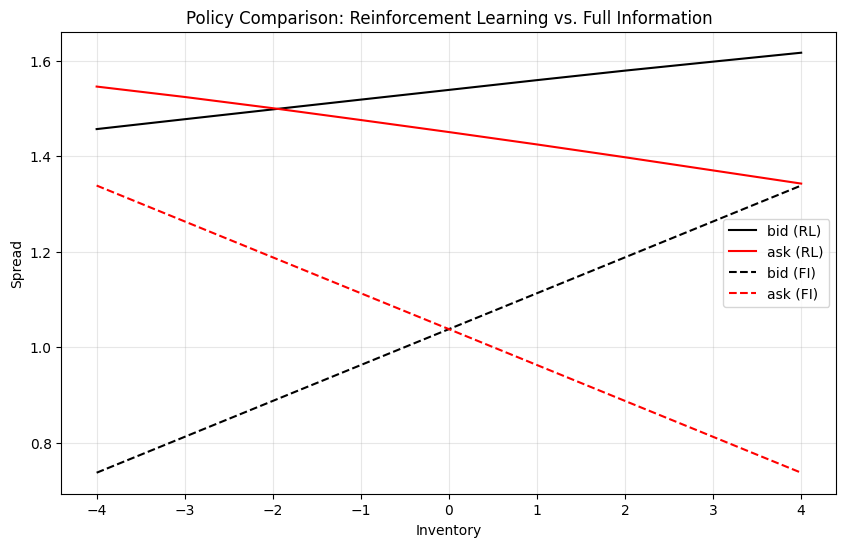

In [42]:
# Create a policy comparison plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(inventories, bid_actions, label="bid (RL)", color="k")
ax.plot(inventories, ask_actions, label="ask (RL)", color="r")
ax.plot(inventories, fi_bid_actions, label="bid (FI)", color="k", linestyle="--")
ax.plot(inventories, fi_ask_actions, label="ask (FI)", color="r", linestyle="--")
ax.legend()
ax.set_xlabel("Inventory")
ax.set_ylabel("Spread")
ax.set_title("Policy Comparison: Reinforcement Learning vs. Full Information")
ax.grid(alpha=0.3)

# Ensure the directory exists
os.makedirs(best_model_path, exist_ok=True)

# Save the figure to the best model path
policy_comparison_filename = os.path.join(best_model_path, "policy_comparison.png")
fig.savefig(policy_comparison_filename, dpi=300, bbox_inches='tight')
print(f"Policy comparison plot saved to {policy_comparison_filename}")

### Dependence of policy on time

In [45]:
# Function to create the plot comparing PPO and FI agents
def plot_policy_time_dependence(ppo_agent, fi_agent):
    # Time points to evaluate
    times = np.linspace(0, terminal_time, n_steps+1)  # 0 to 30 seconds
    inventories = np.array([-3, -2, -1, 0, 1, 2, 3])
    
    # Colors for different inventory levels
    colors = {
        -3: 'blue',
        -2: 'orange',
        -1: 'green',
        0: 'red',
        1: 'salmon',
        2: 'purple',
        3: 'brown'
    }
    
    # Create figure with 2x2 subplots
    fig = plt.figure(figsize=(15, 10))
    gs = GridSpec(2, 2, width_ratios=[1, 1])
    
    ax1 = plt.subplot(gs[0, 0])  # RL bid
    ax2 = plt.subplot(gs[0, 1])  # CJ bid
    ax3 = plt.subplot(gs[1, 0])  # RL ask
    ax4 = plt.subplot(gs[1, 1])  # CJ ask
    
    price = 100.0  # Fixed price for evaluation
    if use_normalized_agent:
        price_normalized = 0  # Normalize price to [-1, 1]
    else:
        price_normalized = price  # Assuming no normalization for price in this context

    fad = 0.0  # Fixed fad for evaluation
    if use_normalized_agent:
        fad_normalized = -1  # Normalize fad to [-1, 1]
    else:
        fad_normalized = fad # Assuming no normalization for fad in this context


    # For each inventory level
    for inv in inventories:
        rl_bids = []
        rl_asks = []
        fi_bids = []
        fi_asks = []

        inv_normalised = normalize_inventory(inv, max_inventory, use_normalized=use_normalized_agent, inverse=False)

        # For each time point
        for t in times:
            if use_normalized_agent:
                normalized_time = (t) / (1/2) - 1
            else:   
                normalized_time = t
            
            # Get PPO agent's actions
            rl_bid, rl_ask = ppo_agent.get_action(np.array([[inv_normalised, normalized_time, price_normalized, fad_normalized]])).reshape(-1)
            rl_bids.append(rl_bid)
            rl_asks.append(rl_ask)
            
            # Get FI agent's actions
            fi_bid, fi_ask = fi_agent.get_action(np.array([[0, inv, t, price, fad]])).reshape(-1)
            fi_bids.append(fi_bid)
            fi_asks.append(fi_ask)

        # Plot the data
        ax1.plot(times, rl_bids, label=f"Inventory = {inv}", color=colors[inv])
        ax2.plot(times, fi_bids, label=f"Inventory = {inv}", color=colors[inv])
        ax3.plot(times, rl_asks, label=f"Inventory = {inv}", color=colors[inv])
        ax4.plot(times, fi_asks, label=f"Inventory = {inv}", color=colors[inv])
    
    # Setting titles and labels
    ax1.set_title("RL δ^bid")
    ax2.set_title("FI δ^bid")
    ax3.set_title("RL δ^ask")
    ax4.set_title("FI δ^ask")
    
    for ax in [ax1, ax2, ax3, ax4]:
        ax.set_xlabel("Time (secs)")
        ax.set_xlim(0, terminal_time)
        ax.grid(True, alpha=0.3)
    
    # Add a legend to the first subplot
    ax1.legend()
    
    plt.suptitle("Dependence of policy on time", fontsize=16)
    plt.tight_layout()
    
    # Add an overall figure caption
    fig.text(0.5, 0.01, "Figure 5: Learnt PPO agent versus CarteaJaimungalAgent as a function of time.", 
             ha='center', fontsize=12)
    
    plt.show()

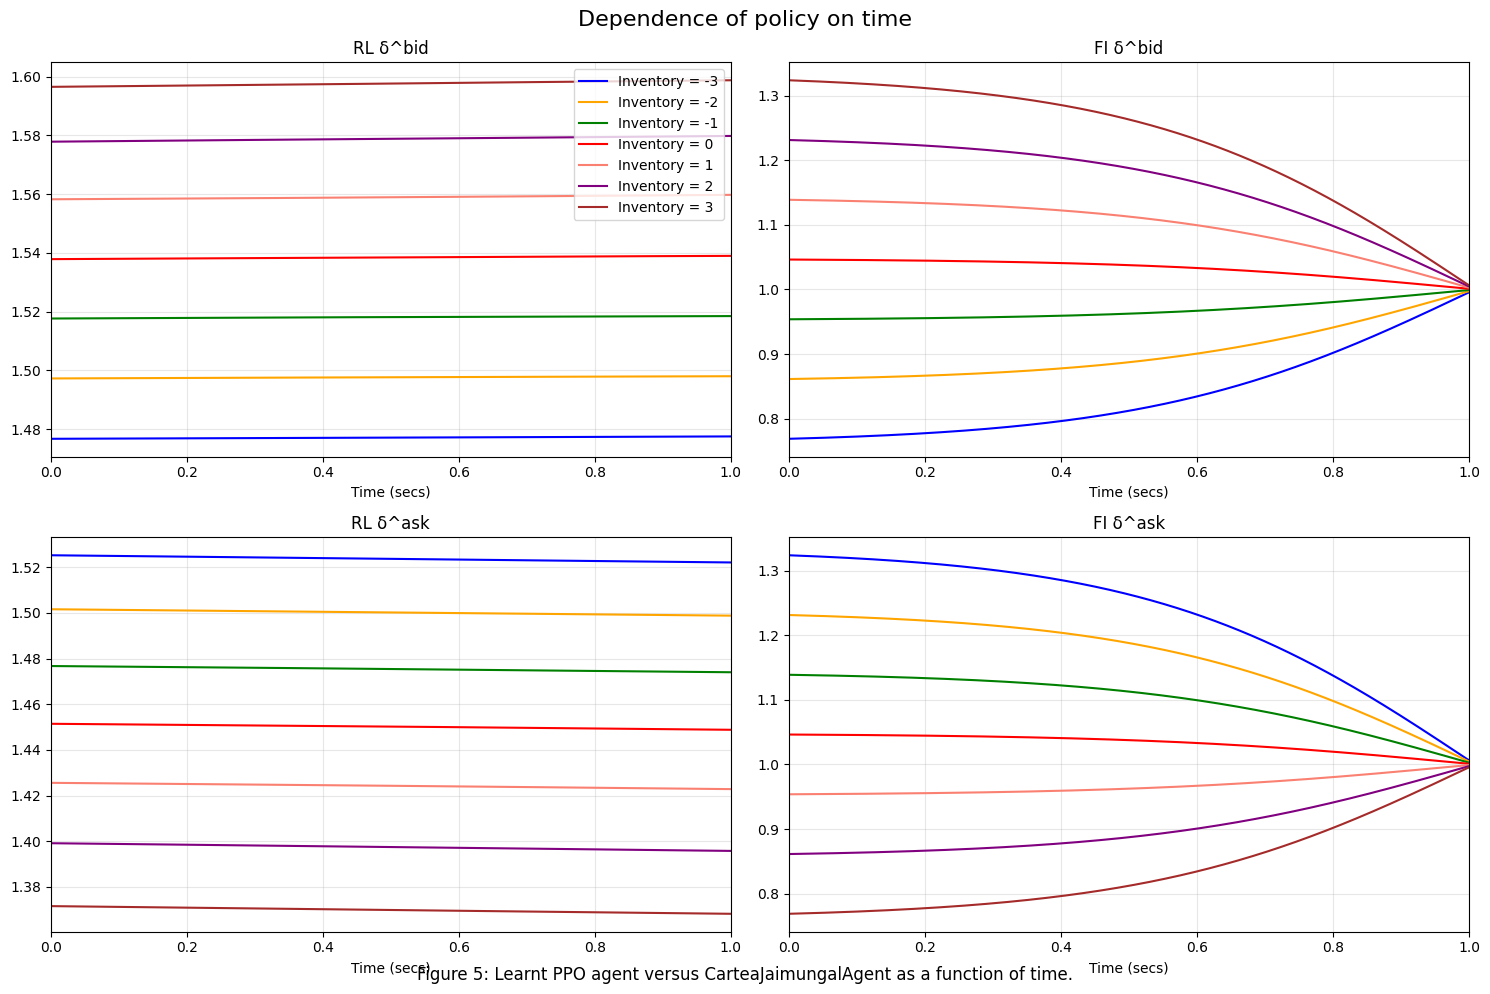

In [47]:
plot_policy_time_dependence(ppo_agent, fi_agent)

In [48]:
def plot_policy_time_dependence(ppo_agent, cj_agent):
    # Time points to evaluate
    times = np.linspace(0, terminal_time, n_steps+1)  # 0 to 30 seconds
    inventories = np.array([-3, -2, -1, 0, 1, 2, 3])
    
    # Colors for different inventory levels
    colors = {
        -3: 'blue',
        -2: 'orange',
        -1: 'green',
        0: 'red',
        1: 'salmon',
        2: 'purple',
        3: 'brown'
    }
    
    # Create figure with 2x2 subplots
    fig = plt.figure(figsize=(15, 10))
    gs = GridSpec(2, 2, width_ratios=[1, 1])
    
    ax1 = plt.subplot(gs[0, 0])  # RL bid
    ax2 = plt.subplot(gs[0, 1])  # CJ bid
    ax3 = plt.subplot(gs[1, 0])  # RL ask
    ax4 = plt.subplot(gs[1, 1])  # CJ ask
    
    price = 100.0  # Fixed price for evaluation
    if use_normalized_agent:
        price_normalized = 0  # Normalize price to [-1, 1]
    else:
        price_normalized = price  # Assuming no normalization for price in this context

    fad = 0.0  # Fixed fad for evaluation
    if use_normalized_agent:
        fad_normalized = -1  # Normalize fad to [-1, 1]
    else:
        fad_normalized = fad # Assuming no normalization for fad in this context


    # Track global min/max for all plots
    global_min = float('inf')
    global_max = float('-inf')
    
    # Store all data to plot later
    all_data = []

    # For each inventory level
    for inv in inventories:
        rl_bids = []
        rl_asks = []
        cj_bids = []
        cj_asks = []
        
        inv_normalised = normalize_inventory(inv, max_inventory, use_normalized=use_normalized_agent, inverse=False)

        # For each time point
        for t in times:
            if use_normalized_agent:
                normalized_time = (t) / (1/2) - 1
            else:   
                normalized_time = t
            
            # Get PPO agent's actions
            rl_bid, rl_ask = ppo_agent.get_action(np.array([[inv_normalised, normalized_time, price_normalized, fad_normalized]])).reshape(-1)
            rl_bids.append(rl_bid)
            rl_asks.append(rl_ask)
            
            # Get CJ agent's actions
            cj_bid, cj_ask = cj_agent.get_action(np.array([[0, inv, t, price, fad]])).reshape(-1)
            cj_bids.append(cj_bid)
            cj_asks.append(cj_ask)
        
        # Update global min/max
        global_min = min(global_min, min(rl_bids), min(rl_asks), min(cj_bids), min(cj_asks))
        global_max = max(global_max, max(rl_bids), max(rl_asks), max(cj_bids), max(cj_asks))
        
        # Store data for later plotting
        all_data.append((inv, rl_bids, rl_asks, cj_bids, cj_asks))
    
    # Now plot all data with the same y-axis scale
    for inv, rl_bids, rl_asks, cj_bids, cj_asks in all_data:
        ax1.plot(times, rl_bids, label=f"Inventory = {inv}", color=colors[inv])
        ax2.plot(times, cj_bids, label=f"Inventory = {inv}", color=colors[inv])
        ax3.plot(times, rl_asks, label=f"Inventory = {inv}", color=colors[inv])
        ax4.plot(times, cj_asks, label=f"Inventory = {inv}", color=colors[inv])
    
    # Apply the same y-axis limits to all subplots
    for ax in [ax1, ax2, ax3, ax4]:
        ax.set_ylim(global_min, global_max)
    
    # Setting titles and labels
    ax1.set_title("RL δ^bid")
    ax2.set_title("CJP δ^bid")
    ax3.set_title("RL δ^ask")
    ax4.set_title("CJP δ^ask")
    
    for ax in [ax1, ax2, ax3, ax4]:
        ax.set_xlabel("Time (secs)")
        ax.set_xlim(0, terminal_time)
        ax.grid(True, alpha=0.3)
    
    # Add a legend to the first subplot
    ax1.legend()
    
    plt.suptitle("Dependence of policy on time", fontsize=16)
    plt.tight_layout()
    
    # Add an overall figure caption
    fig.text(0.5, 0.01, "Figure 5: Learnt PPO agent versus CarteaJaimungalAgent as a function of time.", 
             ha='center', fontsize=12)
    
    plt.show()
    return fig

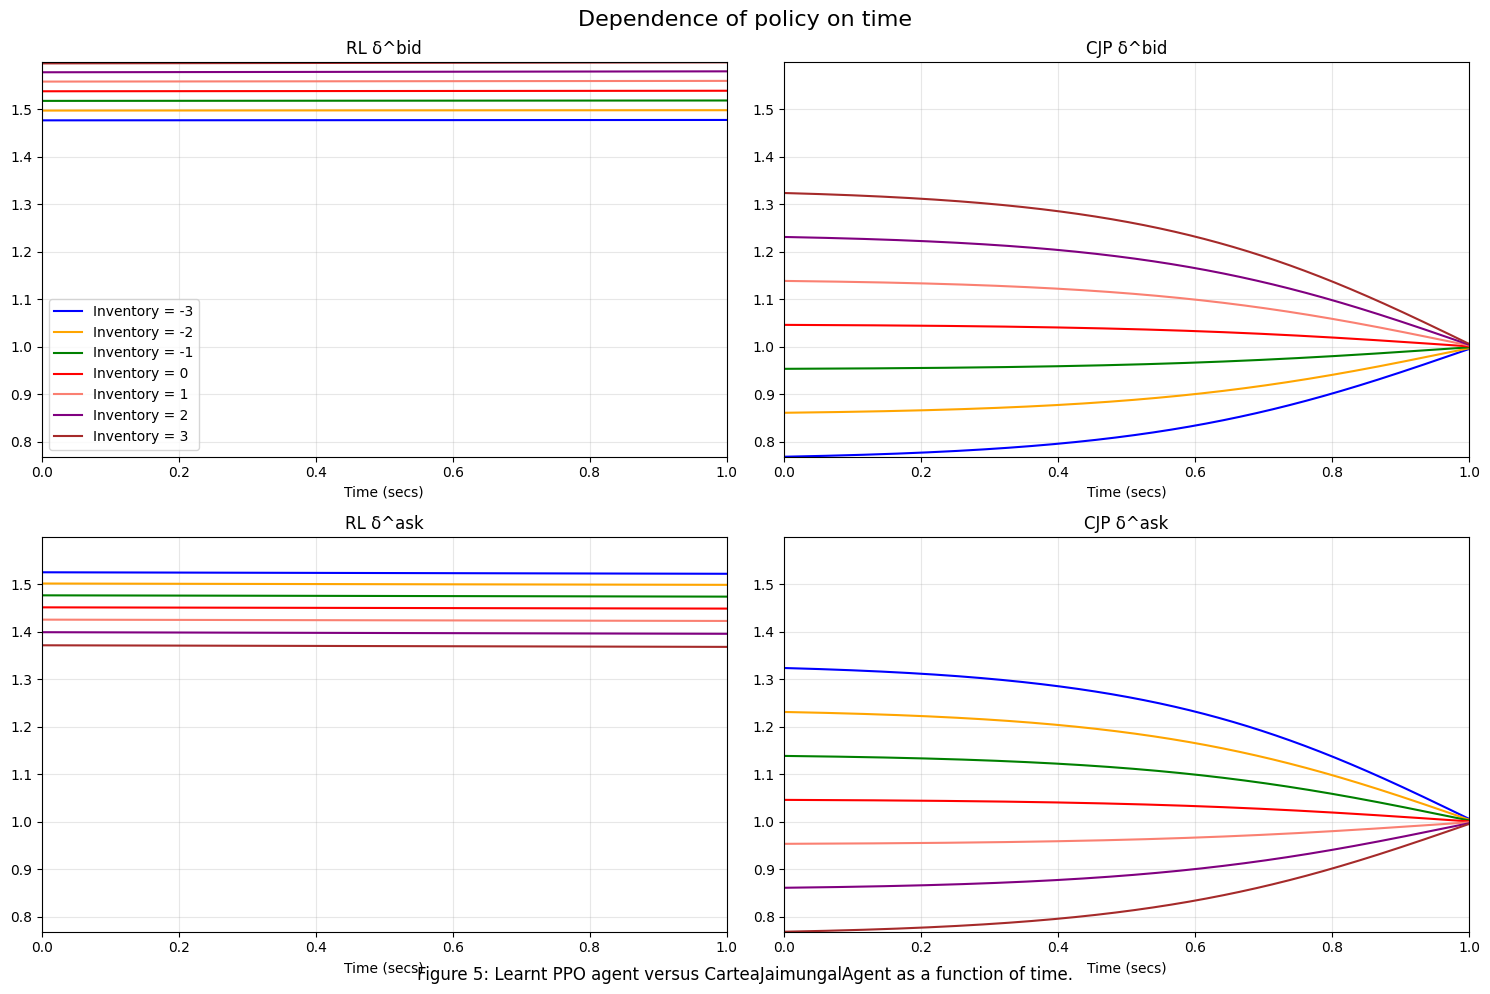

Plot saved to ./Full_Info_models/PPO-best/FI_PPO_Optuna_Best/2025-11-03_12-33-29/policy_time_dependence.png


In [50]:
# Ensure the directory exists
os.makedirs(best_model_path, exist_ok=True)

# Create the plot
fig = plot_policy_time_dependence(ppo_agent, fi_agent)

# Save the figure to the best model path
plot_filename = os.path.join(best_model_path, "policy_time_dependence.png")
fig.savefig(plot_filename, dpi=300, bbox_inches='tight')
print(f"Plot saved to {plot_filename}")

In [51]:
total_rewards = rewards_rl.sum(axis=-1).reshape(-1)
print('mean: ',np.mean(total_rewards))
print('median: ',np.median(total_rewards))
print('std: ',np.std(total_rewards))

mean:  19.311954083070148
median:  18.740359282881954
std:  5.552040328778701


In [60]:

# Generate paths
run_id = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
experiment_name = "FI_PPO_Optuna_Best"
tensorboard_logdir = f".././Full_Info_models/tensorboard/PPO-learning/{experiment_name}/{run_id}/"
best_model_path = f".././Full_Info_models/PPO-best/{experiment_name}/{run_id}/"

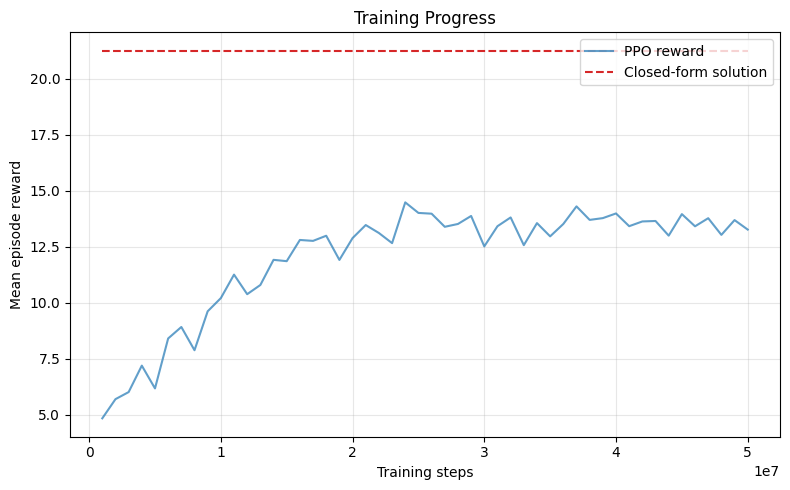

FileNotFoundError: [Errno 2] No such file or directory: '.././Full_Info_models/PPO-best/FI_PPO_Optuna_Best/2025-11-03_13-43-00/Training_process_rollout_reward.png'

In [61]:
# Load the event file
event_file = ".././Full_Info_models/tensorboard/PPO-learning-FI/FI_PPO_Optuna_Best/2025-11-03_12-33-29/PPO_1/events.out.tfevents.1762169609.MacBookAir.lan.40256.0"
# Load the data
ea = event_accumulator.EventAccumulator(event_file)
ea.Reload()
# Extract the rollout/ep_rew_mean data
tag = "rollout/ep_rew_mean"
events = ea.Scalars(tag)
steps = [event.step for event in events]
rewards = [event.value for event in events]

# Plot the rewards
fig, ax = plt.subplots(figsize=(8, 5))

# Plot the rewards
ax.plot(steps, rewards, '-', color='tab:blue', label='PPO reward', alpha=0.7)

# Add the baseline from Cartea-Jaimungal
y_line = float(results_fi["Mean PnL"].iloc[0])
ax.hlines(y=y_line, xmin=min(steps), xmax=max(steps), 
          linestyles='--', color='tab:red',
          label='Closed-form solution')

# Formatting
plt.grid(alpha=0.3)
plt.xlabel('Training steps')
plt.ylabel('Mean episode reward')
plt.title('Training Progress')
plt.legend()
plt.tight_layout()
plt.show()

# Save the figure to the best model path
plot_filename = os.path.join(best_model_path, "Training_process_rollout_reward.png")
fig.savefig(plot_filename, dpi=300, bbox_inches='tight')
print(f"Plot saved to {plot_filename}")

{'images': [], 'audio': [], 'histograms': [], 'scalars': ['rollout/ep_len_mean', 'rollout/ep_rew_mean', 'time/fps', 'train/approx_kl', 'train/clip_fraction', 'train/clip_range', 'train/entropy_loss', 'train/explained_variance', 'train/learning_rate', 'train/loss', 'train/policy_gradient_loss', 'train/std', 'train/value_loss', 'eval/mean_ep_length', 'eval/mean_reward'], 'distributions': [], 'tensors': [], 'graph': False, 'meta_graph': False, 'run_metadata': []}


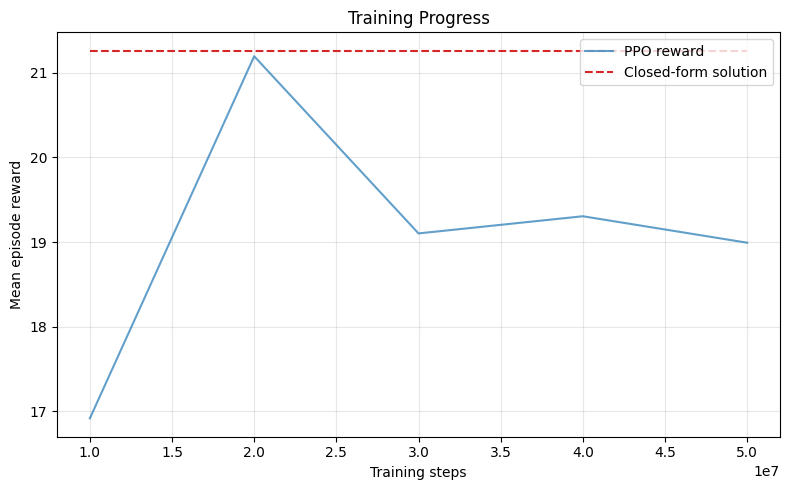

FileNotFoundError: [Errno 2] No such file or directory: '.././Full_Info_models/PPO-best/FI_PPO_Optuna_Best/2025-11-03_13-43-00/Training_process_eval_reward.png'

In [63]:
# Load the event file
event_file = ".././Full_Info_models/tensorboard/PPO-learning-FI/FI_PPO_Optuna_Best/2025-11-03_12-33-29/PPO_1/events.out.tfevents.1762169609.MacBookAir.lan.40256.0"
# Load the data
ea = event_accumulator.EventAccumulator(event_file)
ea.Reload()
# Extract the eval/ep_rew_mean data
tag = "eval/mean_reward"
print(ea.Tags())
events = ea.Scalars(tag)
steps = [event.step for event in events]
rewards = [event.value for event in events]

# Plot the rewards
fig, ax = plt.subplots(figsize=(8, 5))

# Plot the rewards
ax.plot(steps, rewards, '-', color='tab:blue', label='PPO reward', alpha=0.7)

# Add the baseline from Cartea-Jaimungal
y_line = float(results_fi["Mean PnL"].iloc[0])
ax.hlines(y=y_line, xmin=min(steps), xmax=max(steps), 
          linestyles='--', color='tab:red',
          label='Closed-form solution')

# Formatting
plt.grid(alpha=0.3)
plt.xlabel('Training steps')
plt.ylabel('Mean episode reward')
plt.title('Training Progress')
plt.legend()
plt.tight_layout()
plt.show()

# Save the figure to the best model path
plot_filename = os.path.join(best_model_path, "Training_process_eval_reward.png")
fig.savefig(plot_filename, dpi=300, bbox_inches='tight')
print(f"Plot saved to {plot_filename}")

Available tags: {'images': [], 'audio': [], 'histograms': [], 'scalars': ['rollout/ep_len_mean', 'rollout/ep_rew_mean', 'time/fps', 'train/approx_kl', 'train/clip_fraction', 'train/clip_range', 'train/entropy_loss', 'train/explained_variance', 'train/learning_rate', 'train/loss', 'train/policy_gradient_loss', 'train/std', 'train/value_loss', 'eval/mean_ep_length', 'eval/mean_reward'], 'distributions': [], 'tensors': [], 'graph': False, 'meta_graph': False, 'run_metadata': []}


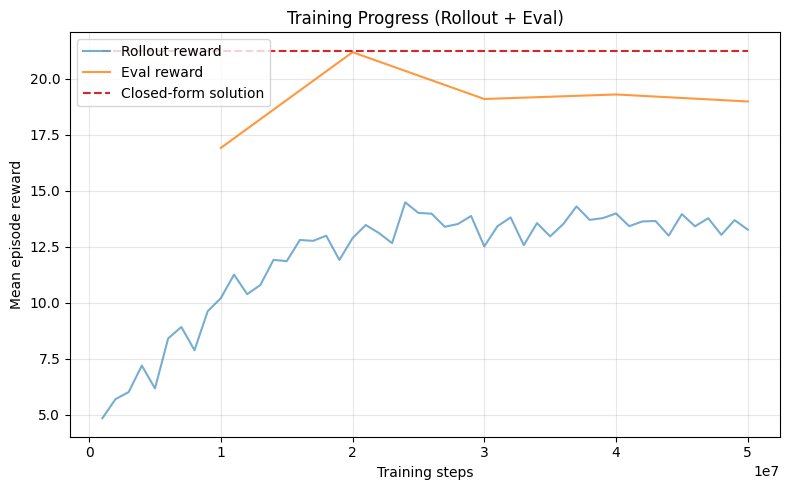

FileNotFoundError: [Errno 2] No such file or directory: '.././Full_Info_models/PPO-best/FI_PPO_Optuna_Best/2025-11-03_13-43-00/Training_process_rewards.png'

In [65]:
# === Load rollout rewards ===
# Load the event file
rollout_file = ".././Full_Info_models/tensorboard/PPO-learning-FI/FI_PPO_Optuna_Best/2025-11-03_12-33-29/PPO_1/events.out.tfevents.1762169609.MacBookAir.lan.40256.0"
ea_rollout = event_accumulator.EventAccumulator(rollout_file)
ea_rollout.Reload()

# === Load eval rewards ===
eval_file = rollout_file  # same file if training and eval in same run
ea_eval = event_accumulator.EventAccumulator(eval_file)
ea_eval.Reload()

# Extract rollout and eval data
rollout_tag = "rollout/ep_rew_mean"
eval_tag = "eval/mean_reward"

# Make sure both tags exist
print("Available tags:", ea_rollout.Tags())

rollout_events = ea_rollout.Scalars(rollout_tag)
eval_events = ea_eval.Scalars(eval_tag)

rollout_steps = [e.step for e in rollout_events]
rollout_rewards = [e.value for e in rollout_events]

eval_steps = [e.step for e in eval_events]
eval_rewards = [e.value for e in eval_events]

# === Plot both ===
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(rollout_steps, rollout_rewards, '-', color='tab:blue', label='Rollout reward', alpha=0.6)
ax.plot(eval_steps, eval_rewards, '-', color='tab:orange', label='Eval reward', alpha=0.8)

# Add baseline line
y_line = float(results_fi["Mean PnL"].iloc[0])
ax.hlines(y=y_line, xmin=min(rollout_steps + eval_steps), xmax=max(rollout_steps + eval_steps),
          linestyles='--', color='tab:red', label='Closed-form solution')

# Formatting
ax.grid(alpha=0.3)
ax.set_xlabel('Training steps')
ax.set_ylabel('Mean episode reward')
ax.set_title('Training Progress (Rollout + Eval)')
ax.legend()
plt.tight_layout()
plt.show()

# Save the figure
plot_filename = os.path.join(best_model_path, "Training_process_rewards.png")
fig.savefig(plot_filename, dpi=300, bbox_inches='tight')
print(f"Plot saved to {plot_filename}")
